# End-to-End Portfolio Optimization — GMV with CNN-GARCH

**Goal**: Replace inverse-variance weighting with a full **Global Minimum Variance (GMV)** optimization,
using CNN-GARCH predicted volatilities combined with historical rolling correlations.

## Formula
$$\Sigma(t) = D(t) \cdot \text{Corr}_{90d}(t) \cdot D(t), \quad D(t) = \text{diag}(\sigma_{\text{NN}}(t))$$
$$w(t) = \arg\min_{w} \; w^\top \Sigma(t) w \quad \text{s.t.} \; \sum w_i = 1, \; w_i \geq 0, \; w_i \leq 10\%$$

## Strategies compared
1. **GMV-GARCH** — GARCH(1,1) vols + rolling correlations (baseline)
2. **GMV-NN** — CNN-GARCH vols + rolling correlations (our model)
3. **GMV-NN-Clean** — CNN-GARCH vols + RIENet-cleaned inverse correlation ← main innovation

Inspired by: *Bongiorno et al. (2025) — End-to-End Large Portfolio Optimization*


In [44]:
from __future__ import annotations
import warnings, sys, time
import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import matplotlib.pyplot as plt
import cvxpy as cp

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from model import HybridGarch
from data_stocks_WIKI_price import get_cleaned_data
from rienet_torch import CorrelationEigenTransformLayer, EigenWeightsLayer

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | cvxpy {cp.__version__} | PyTorch {torch.__version__}')


TensorFlow 2.20.0 | NumPy 2.4.3 | cvxpy 1.8.2 | PyTorch 2.10.0+cpu


In [45]:
pip install rienet_torch


Note: you may need to restart the kernel to use updated packages.


In [46]:
# ── Configuration ─────────────────────────────────────────────────────────────
FILE_PATH   = r'C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip'
CHECKPOINT  = r'../finetune_real_zeroaware_r2min1e8_best.weights.h5'

WINDOW_SIZE = 90      # rolling window — CNN input & correlation window
N_STOCKS    = 30
TRAIN_RATIO = 0.70
ANNUALIZE   = 252
MAX_WEIGHT  = 0.10    # 10% cap per stock (3 x 1/N for N=30)

print(f'Window : {WINDOW_SIZE} | Max weight : {MAX_WEIGHT:.0%}')

Window : 90 | Max weight : 10%


## 1. Data Loading

In [47]:
returns_df_full = get_cleaned_data(FILE_PATH)
print(f'Full universe : {returns_df_full.shape[0]} days x {returns_df_full.shape[1]} stocks')
print(f'Date range    : {returns_df_full.index[0].date()} -> {returns_df_full.index[-1].date()}')

# Select first N_STOCKS (same as Portfolio.ipynb)
selected   = returns_df_full.columns[:N_STOCKS].tolist()
returns_df = returns_df_full[selected].copy()
print(f'\nPortfolio : {N_STOCKS} stocks -> {selected[:5]} ...')

[get_cleaned_data] Universe after filters : 1338 stocks (price≥$3.0 on 2012-10-04, max consec zeros ≤ 20)
Full universe : 4585 days x 1338 stocks
Date range    : 2000-01-04 -> 2018-03-27

Portfolio : 30 stocks -> ['A', 'AAN', 'AAON', 'AAPL', 'ABAX'] ...


## 2. Train / Test Split

In [48]:
n_total   = len(returns_df)
split_idx = int(TRAIN_RATIO * n_total)
start_t   = max(WINDOW_SIZE, split_idx)

returns_train = returns_df.iloc[:split_idx]
returns_test  = returns_df.iloc[split_idx:]
test_dates    = returns_df.index[start_t:]

returns_arr  = returns_df.values.astype(np.float32)   # [T, N]
train_means  = returns_train.mean().values.astype(np.float32)
train_stds   = returns_train.std(ddof=0).values.astype(np.float32)

print(f'Train : {returns_train.index[0].date()} -> {returns_train.index[-1].date()} ({len(returns_train)} days)')
print(f'Test  : {returns_test.index[0].date()}  -> {returns_test.index[-1].date()}  ({len(returns_test)} days)')
print(f'start_t = {start_t} | test_len = {len(test_dates)}')

Train : 2000-01-04 -> 2012-10-03 (3209 days)
Test  : 2012-10-04  -> 2018-03-27  (1376 days)
start_t = 3209 | test_len = 1376


## 3. Load CNN-GARCH Model

In [49]:
model = HybridGarch(hidden=32, kernel=3, conv_layers=5)
# Build the model with a dummy input so weights are created before loading
dummy_input = tf.zeros((1, WINDOW_SIZE, 1))
_ = model(dummy_input, training=False)
model.load_weights(CHECKPOINT)
print(f'Model loaded : {model.count_params():,} parameters')

Model loaded : 14,499 parameters


## 4. Volatility Estimation Functions

In [50]:
def _predict_nn_batch(windows_norm, model):
    x = tf.constant(windows_norm, dtype=tf.float32)
    x = tf.expand_dims(x, axis=-1)  # [N, W, 1]
    sigma2_norm, _, _, _ = model(x, training=False)
    return sigma2_norm.numpy()


def precompute_sigma2_nn(returns_arr, train_means, train_stds, model,
                         window_size, start_t, annualize=252):
    T, N = returns_arr.shape
    sigma2_mat = np.full((T - start_t, N), np.nan)
    eps = 1e-8
    for k, t in enumerate(range(start_t, T)):
        windows = returns_arr[t - window_size:t, :]
        if np.isnan(windows).any():
            continue
        wn = (windows.T - train_means[:, None]) / (train_stds[:, None] + eps)
        s2 = _predict_nn_batch(wn, model) * (train_stds + eps) ** 2
        sigma2_mat[k] = np.clip(s2, 1e-10, None) * annualize
    return sigma2_mat


def precompute_sigma2_arch(returns_arr, train_means, split_idx, start_t, annualize=252):
    from arch import arch_model as arch_fit
    T, N = returns_arr.shape
    sigma2_mat = np.zeros((T - start_t, N))
    for j in range(N):
        r_j = returns_arr[:split_idx, j].astype(np.float64)
        try:
            res = arch_fit(r_j * 100, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
            omega = res.params['omega'] / 1e4
            alpha = res.params['alpha[1]']
            beta  = res.params['beta[1]']
            s2    = float(res.conditional_volatility[-1] ** 2)
        except Exception:
            omega, alpha, beta = 1e-6, 0.05, 0.90
            s2 = np.var(r_j, ddof=0)
        for t in range(split_idx, T):
            s2 = omega + alpha * returns_arr[t-1, j]**2 + beta * s2
            s2 = max(s2, 1e-10)
            if t >= start_t:
                sigma2_mat[t - start_t, j] = s2 * annualize
    return sigma2_mat


print('Volatility functions defined.')

Volatility functions defined.


## 5. Compute Sigma² Matrices

In [51]:
print('[1/2] CNN-GARCH forward pass...')
t0 = time.time()
sigma2_nn = precompute_sigma2_nn(
    returns_arr, train_means, train_stds, model, WINDOW_SIZE, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print('[2/2] GARCH(1,1) recursion...')
t0 = time.time()
sigma2_arch = precompute_sigma2_arch(
    returns_arr.astype(np.float64), train_means, split_idx, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print(f'\nShape: {sigma2_nn.shape}  [test_days x N_stocks]')

[1/2] CNN-GARCH forward pass...
      OK (66.1s)
[2/2] GARCH(1,1) recursion...
      OK (0.6s)

Shape: (1376, 30)  [test_days x N_stocks]


## 6. GMV Portfolio Optimization

### Rolling Correlation + Covariance Construction

At each day $t$:
$$\Sigma(t) = D(t) \cdot \hat{C}_{t-90:t} \cdot D(t)$$
where $D(t) = \text{diag}(\hat{\sigma}_i(t))$ from CNN-GARCH or GARCH, and $\hat{C}$ is the rolling sample correlation matrix.

In [52]:
def rolling_correlation(returns_arr, t, window_size):
    """Sample correlation matrix from returns[t-window:t]."""
    window = returns_arr[t - window_size:t, :]
    w = window - window.mean(axis=0)
    cov = (w.T @ w) / (window_size - 1)
    std = np.maximum(np.sqrt(np.diag(cov)), 1e-10)
    corr = cov / np.outer(std, std)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def nearest_psd(cov, reg=1e-6):
    """Clip negative eigenvalues -> guaranteed PSD."""
    cov = (cov + cov.T) / 2
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, reg)
    cov_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return (cov_psd + cov_psd.T) / 2


# ── RIENet layers ─────────────────────────────────────────────────────────────
corr_cleaner = CorrelationEigenTransformLayer(name="corr_cleaner")
weight_layer  = EigenWeightsLayer(name="gmv_weights")
print('RIENet layers ready: CorrelationEigenTransformLayer + EigenWeightsLayer')


# ── GMV-NN-Clean: full RIENet pipeline ───────────────────────────────────────
def gmv_weights_rienet(sigma2_daily, corr, corr_layer, w_layer,
                        q=None, lookback=None, max_weight=0.10):
    """Compute GMV weights via the full RIENet eigen pipeline.

    Step 1 — CorrelationEigenTransformLayer:
        cleaned eigenvalues + eigenvectors from the noisy sample correlation.
    Step 2 — EigenWeightsLayer:
        w* = D^-1 V Lambda^-1 V^T D^-1 1  (analytical unconstrained GMV)
        where D = diag(sigma), V = eigenvectors, Lambda^-1 = inverse eigenvalues.
    Step 3 — project to long-only + max_weight constraints.
    """
    N = len(sigma2_daily)
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))

    # PyTorch inputs
    corr_t  = torch.tensor(corr[np.newaxis], dtype=torch.float32)   # (1, N, N)
    inv_std = torch.tensor(
        (1.0 / sigma_daily).reshape(1, N, 1), dtype=torch.float32   # (1, N, 1)
    )

    # Optional RIENet attributes: q = T/N ratio, lookback window
    attrs = None
    attr_cols = []
    if q is not None:
        attr_cols.append(float(q))
    if lookback is not None:
        attr_cols.append(float(lookback))
    if attr_cols:
        attrs = torch.tensor([attr_cols], dtype=torch.float32)

    # Step 1: clean correlation -> eigenvectors + inverse_eigenvalues
    details = corr_layer(
        corr_t,
        attributes=attrs,
        output_type=["eigenvectors", "inverse_eigenvalues"],
    )
    eigvecs  = details["eigenvectors"]          # (1, N, N)
    inv_eigs = details["inverse_eigenvalues"]   # (1, N, 1)

    # Step 2: analytical GMV weights  w* = D^-1 V Lambda^-1 V^T D^-1 1
    w_raw = w_layer(eigvecs, inv_eigs, inv_std)  # (1, N)
    w = w_raw[0].detach().numpy().flatten()      # (N,)

    # Step 3: project to long-only + max_weight
    w = np.maximum(w, 0)
    s = w.sum()
    if s < 1e-10:
        return np.ones(N) / N
    w = w / s

    for _ in range(100):
        excess = np.maximum(w - max_weight, 0)
        if excess.sum() < 1e-10:
            break
        w = np.minimum(w, max_weight)
        deficit = 1.0 - w.sum()
        uncapped = w < max_weight - 1e-10
        if uncapped.sum() == 0:
            break
        w[uncapped] += deficit * (w[uncapped] / w[uncapped].sum())

    s = w.sum()
    return w / s if s > 1e-10 else np.ones(N) / N


# ── GMV-GARCH / GMV-NN: standard cvxpy path ──────────────────────────────────
def build_covariance(sigma2_daily, corr):
    """Build raw covariance matrix from GARCH/NN vols + rolling correlation."""
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))
    D = np.diag(sigma_daily)
    return nearest_psd(D @ corr @ D)


def gmv_weights(cov, max_weight=0.10):
    """Long-only GMV via Cholesky + cvxpy (GMV-GARCH and GMV-NN)."""
    N = cov.shape[0]
    cov_psd = nearest_psd(cov)
    try:
        L = np.linalg.cholesky(cov_psd)
    except np.linalg.LinAlgError:
        return np.ones(N) / N

    w = cp.Variable(N)
    objective   = cp.Minimize(cp.sum_squares(L.T @ w))
    constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    if prob.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
        weights = np.maximum(np.array(w.value).flatten(), 0)
        s = weights.sum()
        return weights / s if s > 1e-10 else np.ones(N) / N
    return np.ones(N) / N


print('GMV functions defined.')
print('  GMV-GARCH / GMV-NN  : build_covariance + cvxpy')
print('  GMV-NN-Clean        : CorrelationEigenTransformLayer + EigenWeightsLayer')


RIENet layers ready: CorrelationEigenTransformLayer + EigenWeightsLayer
GMV functions defined.
  GMV-GARCH / GMV-NN  : build_covariance + cvxpy
  GMV-NN-Clean        : CorrelationEigenTransformLayer + EigenWeightsLayer


In [53]:
def compute_gmv_portfolio(sigma2_mat, returns_arr, start_t, window_size,
                          max_weight=0.10, label='GMV',
                          corr_layer=None, w_layer=None):
    """Compute daily GMV portfolio returns and weights.

    If corr_layer + w_layer are provided (GMV-NN-Clean):
        uses gmv_weights_rienet — full RIENet eigen pipeline.
    Otherwise (GMV-GARCH, GMV-NN):
        uses build_covariance + gmv_weights (cvxpy).
    """
    test_len = sigma2_mat.shape[0]
    N        = sigma2_mat.shape[1]
    q_ratio  = window_size / N
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))
    use_rienet   = (corr_layer is not None) and (w_layer is not None)

    for k in range(test_len):
        t    = start_t + k
        r_t  = returns_arr[t]
        s2_k = sigma2_mat[k]

        if np.isnan(s2_k).any():
            w = np.ones(N) / N
        elif use_rienet:
            corr = rolling_correlation(returns_arr, t, window_size)
            w = gmv_weights_rienet(
                s2_k, corr,
                corr_layer=corr_layer, w_layer=w_layer,
                q=q_ratio, lookback=float(window_size),
                max_weight=max_weight,
            )
        else:
            corr = rolling_correlation(returns_arr, t, window_size)
            cov  = build_covariance(s2_k, corr)
            w    = gmv_weights(cov, max_weight=max_weight)

        port_returns[k] = np.dot(w, r_t)
        weights_hist[k] = w

        if k % 200 == 0:
            print(f'  [{label}] Day {k}/{test_len} — max_w={w.max():.1%} HHI={(w**2).sum():.3f}')

    return port_returns, weights_hist


print('compute_gmv_portfolio defined.')


compute_gmv_portfolio defined.


## 7. Run All Strategies

In [54]:
print('Computing strategies...')

# 1. GMV-GARCH — GARCH vols + raw rolling correlation -> cvxpy
print('  [1/3] GMV-GARCH...')
t0 = time.time()
r_gmv_arch, w_gmv_arch = compute_gmv_portfolio(
    sigma2_arch, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT, label='GMV-GARCH'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 2. GMV-NN — CNN-GARCH vols + raw rolling correlation -> cvxpy
print('  [2/3] GMV-NN...')
t0 = time.time()
r_gmv_nn, w_gmv_nn = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT, label='GMV-NN'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 3. GMV-NN-Clean — CNN-GARCH vols + RIENet eigen pipeline (no cvxpy)
print('  [3/3] GMV-NN-Clean...')
t0 = time.time()
r_gmv_nn_clean, w_gmv_nn_clean = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT,
    label='GMV-NN-Clean',
    corr_layer=corr_cleaner,
    w_layer=weight_layer,
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('\nAll strategies computed.')


Computing strategies...
  [1/3] GMV-GARCH...
  [GMV-GARCH] Day 0/1376 — max_w=10.0% HHI=0.088
  [GMV-GARCH] Day 200/1376 — max_w=10.0% HHI=0.088
  [GMV-GARCH] Day 400/1376 — max_w=10.0% HHI=0.088
  [GMV-GARCH] Day 600/1376 — max_w=10.0% HHI=0.085
  [GMV-GARCH] Day 800/1376 — max_w=10.0% HHI=0.086
  [GMV-GARCH] Day 1000/1376 — max_w=10.0% HHI=0.095
  [GMV-GARCH] Day 1200/1376 — max_w=10.0% HHI=0.083
        Done (7s)
  [2/3] GMV-NN...
  [GMV-NN] Day 0/1376 — max_w=10.0% HHI=0.086
  [GMV-NN] Day 200/1376 — max_w=10.0% HHI=0.078
  [GMV-NN] Day 400/1376 — max_w=10.0% HHI=0.085
  [GMV-NN] Day 600/1376 — max_w=10.0% HHI=0.080
  [GMV-NN] Day 800/1376 — max_w=10.0% HHI=0.086
  [GMV-NN] Day 1000/1376 — max_w=10.0% HHI=0.092
  [GMV-NN] Day 1200/1376 — max_w=10.0% HHI=0.084
        Done (6s)
  [3/3] GMV-NN-Clean...
  [GMV-NN-Clean] Day 0/1376 — max_w=6.7% HHI=0.039
  [GMV-NN-Clean] Day 200/1376 — max_w=5.5% HHI=0.036
  [GMV-NN-Clean] Day 400/1376 — max_w=7.3% HHI=0.040
  [GMV-NN-Clean] Day 600/13

## 8. Financial Metrics

In [55]:
def financial_metrics(returns, annualize=252):
    r = pd.Series(returns).dropna()
    ann_ret = r.mean() * annualize
    ann_vol = r.std(ddof=0) * np.sqrt(annualize)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-10 else np.nan
    cumret  = (1 + r).cumprod()
    max_dd  = float(((cumret - cumret.cummax()) / cumret.cummax()).min())
    calmar  = ann_ret / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan
    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe'          : round(sharpe, 4),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar'          : round(calmar, 4),
    }


metrics = pd.DataFrame({
    'GMV-GARCH'    : financial_metrics(r_gmv_arch),
    'GMV-NN'       : financial_metrics(r_gmv_nn),
    'GMV-NN-Clean' : financial_metrics(r_gmv_nn_clean),
}).T

print('=' * 60)
print('OUT-OF-SAMPLE PERFORMANCE')
print('=' * 60)
print(metrics.to_string())
print()

best_vol    = metrics['Ann. Vol (%)'].idxmin()
best_sharpe = metrics['Sharpe'].idxmax()
best_dd     = metrics['Max Drawdown (%)'].idxmax()
print(f'Best Volatility  : {best_vol}')
print(f'Best Sharpe      : {best_sharpe}')
print(f'Best Max Drawdown: {best_dd}')


OUT-OF-SAMPLE PERFORMANCE
              Ann. Return (%)  Ann. Vol (%)  Sharpe  Max Drawdown (%)  Calmar
GMV-GARCH               16.73         11.45  1.4613            -12.51  1.3368
GMV-NN                  19.19         11.44  1.6781            -12.54  1.5300
GMV-NN-Clean            19.22         13.02  1.4756            -14.49  1.3266

Best Volatility  : GMV-NN
Best Sharpe      : GMV-NN
Best Max Drawdown: GMV-GARCH


## 9. Visualizations

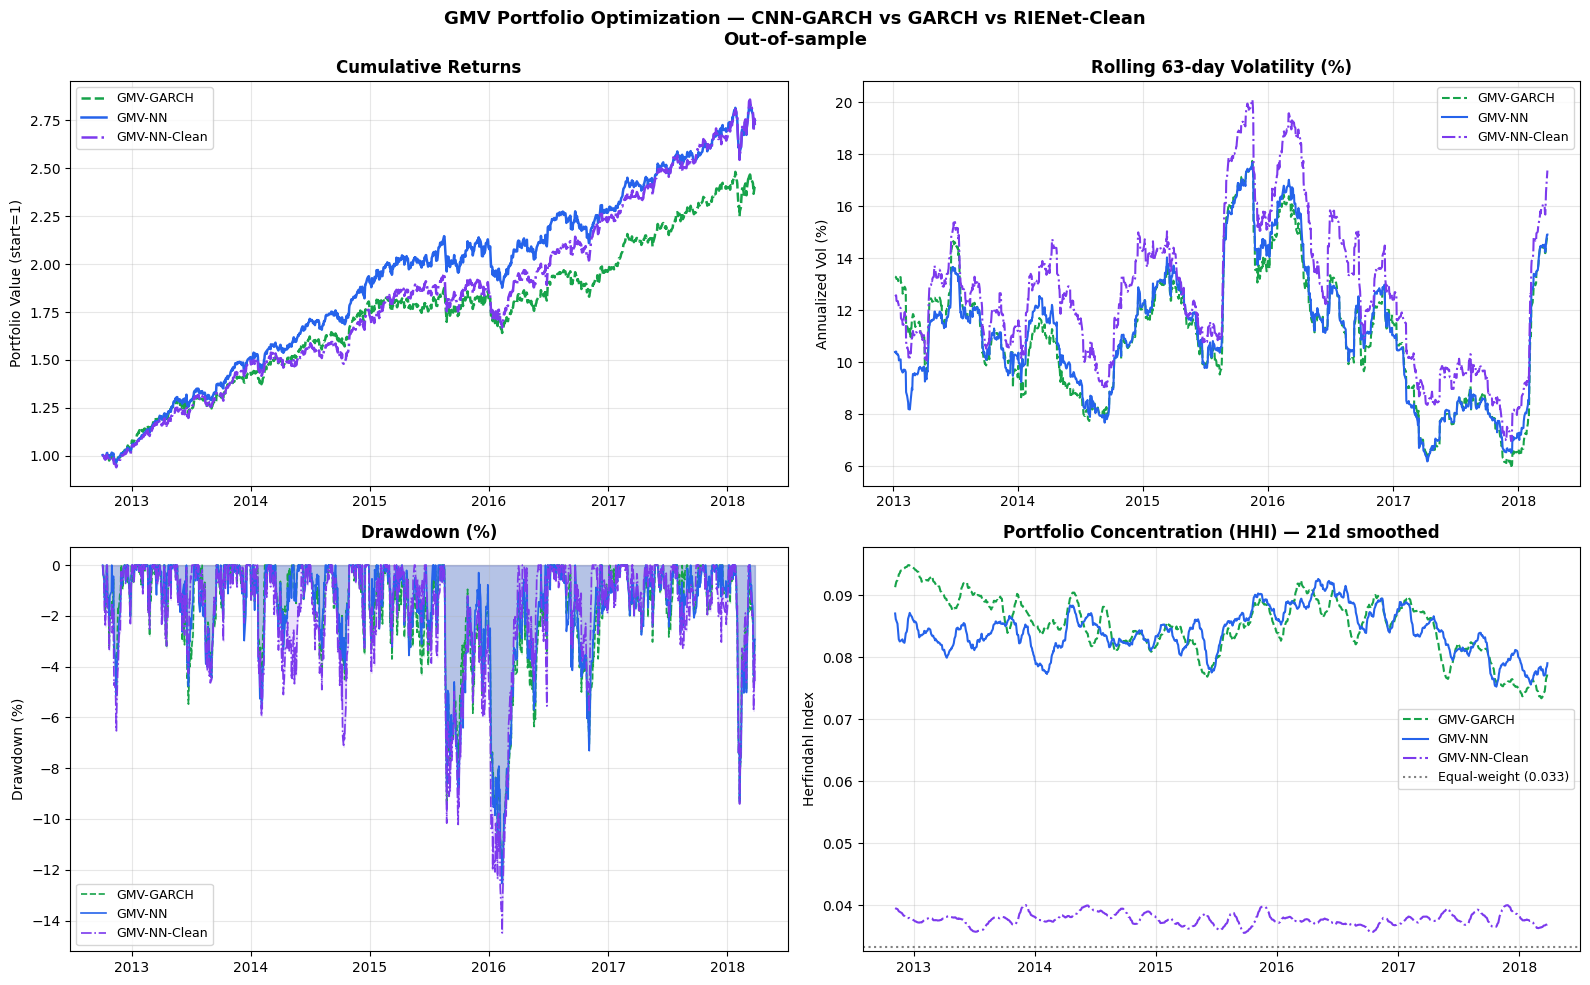

Figure saved: gmv_results.png


In [56]:
_BLUE   = '#2563EB'
_GREEN  = '#16A34A'
_PURPLE = '#7C3AED'

strategies = {
    'GMV-GARCH'    : (r_gmv_arch,      w_gmv_arch,       _GREEN,  '--'),
    'GMV-NN'       : (r_gmv_nn,        w_gmv_nn,         _BLUE,   '-'),
    'GMV-NN-Clean' : (r_gmv_nn_clean,  w_gmv_nn_clean,   _PURPLE, '-.'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GMV Portfolio Optimization — CNN-GARCH vs GARCH vs RIENet-Clean\nOut-of-sample',
             fontsize=13, fontweight='bold')

# 1. Cumulative returns
ax = axes[0, 0]
for name, (r, w, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.8, label=name)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 2. Rolling 63-day volatility
ax = axes[0, 1]
for name, (r, w, col, ls) in strategies.items():
    roll_vol = pd.Series(r, index=test_dates).rolling(63).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol.values, color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('Rolling 63-day Volatility (%)', fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 3. Drawdown
ax = axes[1, 0]
for name, (r, w, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.15, color=col)
    ax.plot(dd.index, dd.values, color=col, linestyle=ls, linewidth=1.2, label=name)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 4. Portfolio concentration (HHI)
ax = axes[1, 1]
for name, (r, w, col, ls) in strategies.items():
    hhi = pd.Series((w**2).sum(axis=1), index=test_dates)
    ax.plot(hhi.index, hhi.rolling(21).mean(), color=col, linestyle=ls, linewidth=1.5, label=name)
ax.axhline(1/N_STOCKS, color='grey', linestyle=':', label=f'Equal-weight ({1/N_STOCKS:.3f})')
ax.set_title('Portfolio Concentration (HHI) — 21d smoothed', fontweight='bold')
ax.set_ylabel('Herfindahl Index')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gmv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gmv_results.png')


In [57]:
N_STOCKS

30

## 10. Full Comparison — All 3 Strategies


In [58]:
all_strategies = {
    'GMV-GARCH'    : (r_gmv_arch,      w_gmv_arch),
    'GMV-NN'       : (r_gmv_nn,        w_gmv_nn),
    'GMV-NN-Clean' : (r_gmv_nn_clean,  w_gmv_nn_clean),
}

all_metrics = {name: financial_metrics(r) for name, (r, _) in all_strategies.items()}

print('=' * 80)
print('FULL COMPARISON — ALL 3 STRATEGIES (Out-of-sample)')
print('=' * 80)

header = f"{'Metric':<22}" + ''.join(f'{name:>16}' for name in all_metrics)
print(header)
print('-' * len(header))

metric_names = list(next(iter(all_metrics.values())).keys())
for m in metric_names:
    vals = [all_metrics[name][m] for name in all_metrics]
    row = f'{m:<22}' + ''.join(f'{v:>16}' for v in vals)
    if 'Vol' in m or 'Drawdown' in m:
        best_name = min(all_metrics, key=lambda n: all_metrics[n][m])
    else:
        best_name = max(all_metrics, key=lambda n: all_metrics[n][m])
    print(row + f'   <- best: {best_name}')

print(f'\n{"─" * 80}')
print(f'{"WEIGHT CONCENTRATION":<22}' + ''.join(f'{name:>16}' for name in all_strategies))
print('-' * 80)

hhi_row   = f'{"Mean HHI":<22}'
max_w_row = f'{"Mean Max Weight":<22}'
for name, (_, w) in all_strategies.items():
    hhi_row   += f'{(w**2).sum(axis=1).mean():>16.4f}'
    max_w_row += f'{w.max(axis=1).mean():>15.1%} '

print(hhi_row)
print(max_w_row)

print(f'\n{"=" * 80}')
print('EFFECT OF RIENet CLEANING (GMV-NN-Clean vs GMV-NN)')
print('=' * 80)
m_raw   = all_metrics['GMV-NN']
m_clean = all_metrics['GMV-NN-Clean']
for k in metric_names:
    v1, v2 = m_raw[k], m_clean[k]
    if 'Vol' in k or 'Drawdown' in k:
        imp = f'{v1 - v2:+.2f}  (lower is better)' if v2 < v1 else f'{v1 - v2:+.2f}'
    else:
        imp = f'{v2 - v1:+.4f}  (higher is better)' if v2 > v1 else f'{v2 - v1:+.4f}'
    print(f'  {k:<22} {imp}')


FULL COMPARISON — ALL 3 STRATEGIES (Out-of-sample)
Metric                       GMV-GARCH          GMV-NN    GMV-NN-Clean
----------------------------------------------------------------------
Ann. Return (%)                  16.73           19.19           19.22   <- best: GMV-NN-Clean
Ann. Vol (%)                     11.45           11.44           13.02   <- best: GMV-NN
Sharpe                          1.4613          1.6781          1.4756   <- best: GMV-NN
Max Drawdown (%)                -12.51          -12.54          -14.49   <- best: GMV-NN-Clean
Calmar                          1.3368            1.53          1.3266   <- best: GMV-NN

────────────────────────────────────────────────────────────────────────────────
WEIGHT CONCENTRATION         GMV-GARCH          GMV-NN    GMV-NN-Clean
--------------------------------------------------------------------------------
Mean HHI                        0.0852          0.0842          0.0377
Mean Max Weight                 10.0%        